In [1]:
print ("all ok")

all ok


In [23]:
from dotenv import load_dotenv
import os
load_dotenv()

False

In [24]:
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

In [25]:
if not OPENAI_API_KEY:
    raise ValueError("OPENAI_API_KEY is missing in your .env")
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

In [26]:
from langchain_openai import ChatOpenAI

In [27]:
chat_llm = ChatOpenAI(model="gpt-4o-mini")

In [28]:

chat_llm.invoke("Hello, how are you?").content

"Hello! I'm just a computer program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?"

In [29]:
"Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?"

"Hello! I'm just a program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?"

In [30]:

from typing_extensions import TypedDict, Annotated
import operator

In [31]:

from langchain_core.messages import AnyMessage, HumanMessage, AIMessage

In [32]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [33]:
{
    "messages": [HumanMessage(content="Hi, this is Sunny. Say hello in detail.")]
}

{'messages': [HumanMessage(content='Hi, this is Sunny. Say hello in detail.', additional_kwargs={}, response_metadata={})]}

In [34]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response."""
    response = chat_llm.invoke(state["messages"])  # AIMessage
    return {
        "messages": [response]
    }

In [35]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [36]:
from langgraph.graph import StateGraph

In [37]:

builder = StateGraph(GraphState)

In [38]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [39]:

builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [40]:
app = builder.compile()

In [41]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

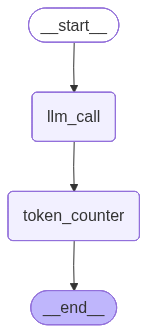

In [42]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [43]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is Sunny. Say hello in detail.")]
})

In [44]:
result

{'messages': [HumanMessage(content='Hi, this is Sunny. Say hello in detail.', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Hello, Sunny! It’s great to connect with you. I hope you're having a wonderful day. If there’s anything specific you’d like to talk about or any questions you have, feel free to share! I'm here to help and chat about whatever interests you. What’s on your mind today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 60, 'prompt_tokens': 18, 'total_tokens': 78, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_fcf1a634a5', 'id': 'chatcmpl-DeJw4wZKxzh781Se45CCt2NXgdfvq', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e

In [45]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is Sunny. Say hello in detail.
AIMessage : Hello, Sunny! It’s great to connect with you. I hope you're having a wonderful day. If there’s anything specific you’d like to talk about or any questions you have, feel free to share! I'm here to help and chat about whatever interests you. What’s on your mind today?
AIMessage : Total token number in the generated answer (word count) is 48


In [46]:
chat_llm

ChatOpenAI(output_version=None, profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x000002CD968BF610>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x000002CD968BFD90>, root_client=<openai.OpenAI object at 0x000002CD968BF750>, root_async_client=<openai.AsyncOpenAI object at 0x000002CD968BF4D0>, model_name='gpt-4o-mini', model_kwargs={}, 

In [47]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper